Shape: (27, 4)


,Metric,Informa (INF),Pearson (PSON),Notes / source context
0,Report date,7 Oct 2026 (BST),7 Oct 2026 (BST),Time‑stamped snapshot; prices move continuously
1,Latest quoted price,866.4p (11:38 BST),"1,216p (close, 22 Sep data point)",Use live quotes before trading
2,Equity market value,£10.78bn,£7.41bn,Informa is materially larger
3,Shares outstanding,1.26bn,601.0m,Different share counts do not indicate cheaper...
4,1‑year share‑price change,-7.4%,+17.2%,Pearson has led recently


TF-IDF shape: (27, 164)

Cluster Results:


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_4722/397828516.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


,text,Cluster
0,Report date 7 Oct 2026 (BST) 7 Oct 2026 (BST) ...,0
1,"Latest quoted price 866.4p (11:38 BST) 1,216p ...",0
2,Equity market value £10.78bn £7.41bn Informa i...,0
3,Shares outstanding 1.26bn 601.0m Different sha...,0
4,1‑year share‑price change -7.4% +17.2% Pearson...,0
5,Trailing P/E (TTM) 50.15x Not consistently ava...,1
6,Forward P/E (2026 estimate) Not consistently a...,0
7,Dividend yield 2.62% c.2.08% Both are modest i...,0
8,Latest cash dividend per share £0.075 (interim...,0
9,Ex‑dividend date (latest) 6 Aug 2026 13 Aug 2026,0


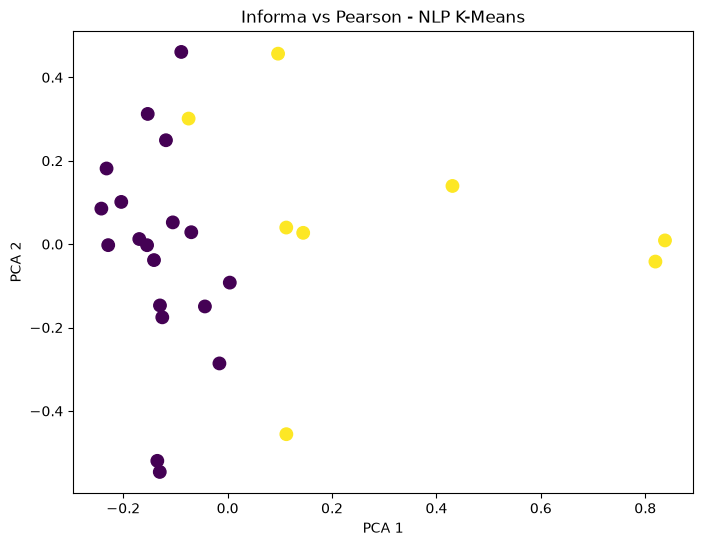

AttributeError: 'Series' object has no attribute 'nonzero'

In [1]:
# ==============================
# INFORMA vs PEARSON
# NLP + K-MEANS
# ==============================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. LOAD DATA
df = pd.read_csv("Informa_vs_Pearson_Equity_Comparison.csv")

print("Shape:", df.shape)
display(df.head())

# 2. CLEAN DATA
df = df.drop_duplicates().dropna(how="all")

# 3. CREATE TEXT DATA
text_cols = df.select_dtypes(include="object").columns

df["text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

def clean_text(x):
    x = x.lower()
    x = re.sub(r"[^a-z\s]", " ", x)
    x = re.sub(r"\s+", " ", x)
    return x

df["clean_text"] = df["text"].apply(clean_text)

# 4. NLP - TF-IDF
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=500
)

X = tfidf.fit_transform(df["clean_text"])

print("TF-IDF shape:", X.shape)

# 5. K-MEANS
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X)

print("\nCluster Results:")
display(df[["text", "Cluster"]])

# 6. PCA VISUALISATION
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"],
    s=80
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Informa vs Pearson - NLP K-Means")
plt.show()

# 7. TOP WORDS
words = tfidf.get_feature_names_out()

for c in sorted(df["Cluster"].unique()):
    scores = X[df["Cluster"] == c].mean(axis=0).A1
    top = scores.argsort()[-10:][::-1]

    print(f"\nCluster {c} Top Words:")
    print([words[i] for i in top])

# 8. NUMERICAL/EQUITY DATA
num_cols = df.select_dtypes(include=np.number).columns
num_cols = [c for c in num_cols if c != "Cluster"]

if len(num_cols) >= 2:

    financial = df[num_cols].fillna(df[num_cols].median())

    scaler = StandardScaler()
    financial_scaled = scaler.fit_transform(financial)

    financial_kmeans = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=10
    )

    df["Financial_Cluster"] = financial_kmeans.fit_predict(
        financial_scaled
    )

    print("\nFinancial Clusters:")
    display(df[["Cluster", "Financial_Cluster"] + num_cols])

# 9. SAVE RESULTS
df.to_csv(
    "Informa_vs_Pearson_NLP_KMeans_Results.csv",
    index=False
)

print("\nAnalysis completed!")